In [296]:
import sys
import os
os.chdir('/zhome/71/c/146676/main/')
import time
import SimpleITK as sitk
import numpy as np
from astropy.io import fits
from helpers import module_auxiliary as ma
import tifffile
from multiprocessing import Pool
import matplotlib.pyplot as plt
from helpers import extended_data as ed
from cil.recon import FBP
#from cil.plugins.astra import FBP
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.optimisation.functions import L2NormSquared, L1Norm, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares
from cil.optimisation.operators import BlockOperator, GradientOperator, IdentityOperator, FiniteDifferenceOperator
from cil.optimisation.algorithms import CGLS, SIRT, GD, FISTA, ISTA, PDHG, SPDHG
from cil.plugins.astra.operators import ProjectionOperator
from cil.optimisation.functions import IndicatorBox, MixedL21Norm, L2NormSquared, \
                                       BlockFunction, L1Norm, LeastSquares, \
                                       OperatorCompositionFunction, TotalVariation, \
                                       ZeroFunction
from cil.optimisation.operators import BlockOperator, GradientOperator,\
                                       GradientOperator
import h5py
from cil.utilities.display import show_geometry
from scipy.ndimage import uniform_filter1d
from cil.processors import Slicer
import cv2
import hdf5plugin

In [297]:

def cartesian_to_polar_opencv(matrix,num_phi=360,num_rad = None):
    rows, cols = matrix.shape
    bias_col = 28
    bias_row = 33
    center = (cols // 2+bias_col, rows // 2+bias_row)  # Define center as origin
    max_radius = (min(cols, rows) // 2)-150
    if num_rad is None:
        num_rad = max_radius
    # Convert Cartesian to Polar using OpenCV's warpPolar
    polar_matrix = cv2.warpPolar(
        matrix, (num_rad, num_phi), center, max_radius,
        cv2.WARP_POLAR_LINEAR + cv2.INTER_LINEAR
    )

    return polar_matrix

In [ ]:
# Open the h5 file in read mode

def DA_loader(batch_id,q_value=0.75):
    Nx = 362
    with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_non_integrated/scan-0339_pilatus.h5', 'r') as file:
        # Check the keys in the file (this shows the main datasets or groups)
        all_polar3 = []
        # Access a dataset or group (replace 'your_dataset' with the correct key)
        for i in range(Nx):
            dataset_ = file['entry']['instrument']['pilatus']['data'][Nx*batch_id + i]  # Replace 'your_dataset' with the actual name of the dataset
            dataset = np.pad(dataset_, 300, mode='constant', constant_values=0)
            dataset[dataset<0] = 0
            polar_matrix = cartesian_to_polar_opencv(dataset.astype(np.float32),num_phi=360, num_rad=500)
            q_max = np.quantile(polar_matrix,q_value,axis=0)
            q_min = np.quantile(polar_matrix,0,axis=0)
            polar2 = np.clip(polar_matrix, q_min, q_max)
            polar3 = np.sum(polar2,axis=0)
            all_polar3.append(polar3)
        return np.stack(all_polar3)


batch_ids = [50,100,150]
q_value = 0.6  # Constant q_value

with Pool() as pool:
    results = pool.starmap(DA_loader, [(batch_id, q_value) for batch_id in batch_ids])

stacked_results = np.stack(results)
np.save('/dtu-compute/msaca/sliceA_diffraction/xrd_non_integrated/filtered_integrations/median_clipped_0_6_.npy', stacked_results)
        

print(stacked_results.shape)

(3, 362, 500)


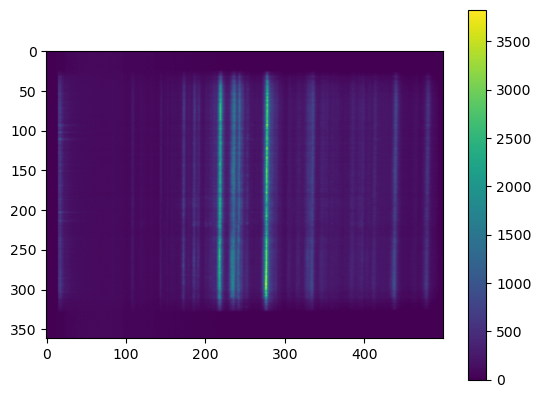

In [295]:
plt.imshow(stacked_results[2])
plt.colorbar()

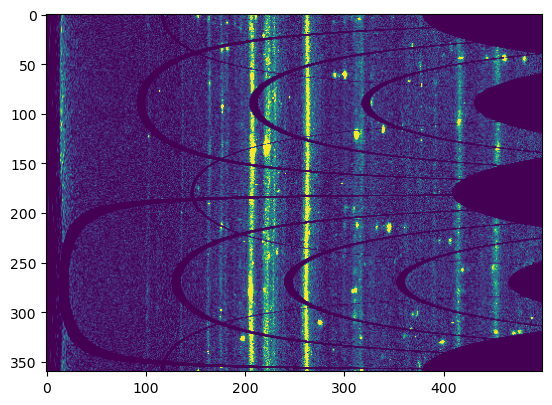

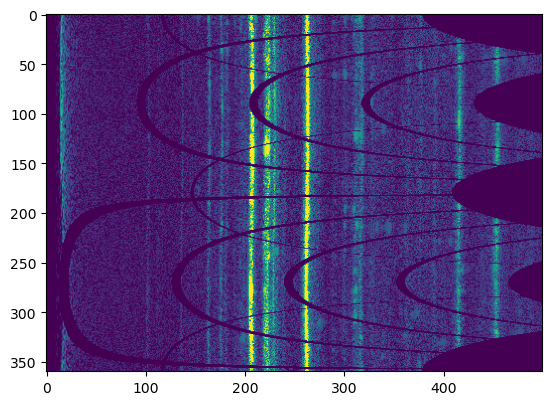

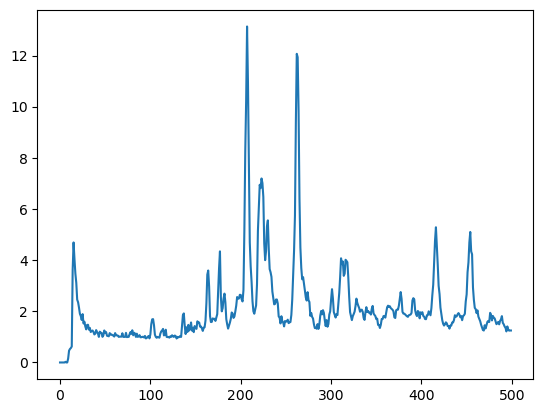

In [ ]:
q_max = np.quantile(polar_matrix,0.90,axis=0)
q_min = np.quantile(polar_matrix,0,axis=0)
polar2 = np.clip(polar_matrix, q_min, q_max)
plt.imshow(polar_matrix)
plt.clim([0,2*3.5])
plt.show()
plt.imshow(polar2)
plt.clim([0,2*3.5])
plt.show()
plt.plot(q_max)
plt.show()

/tmp/pbs.516596.hnode41/ipykernel_1659595/79997825.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(polar_matrix[:,i*25+8]))


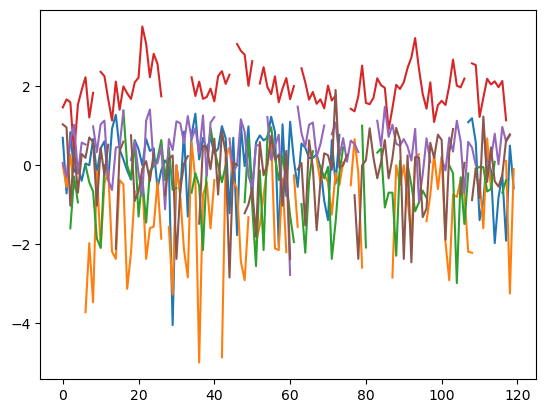

In [236]:
for i in range(6):
    plt.plot(np.log(polar_matrix[:,i*25+8]))
plt.show()

In [ ]:


polar_matrix = cartesian_to_polar_opencv(dataset.astype(np.float32),num_phi=120, num_rad=1000)

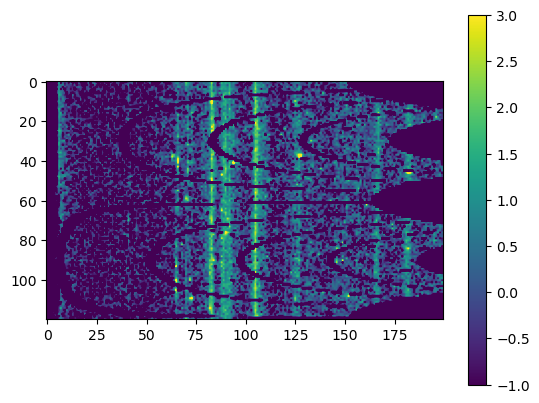

In [222]:
plt.imshow(np.log((polar_matrix+0.001)))
plt.colorbar()
plt.clim([-1,3])

(1679, 1475)


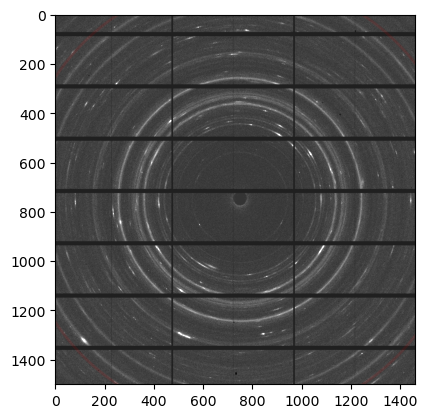

In [202]:
import matplotlib.patches as patches
ny, nx = np.shape(dataset)
print(np.shape(dataset))
D = 750
dy = 33
dx = 28
center = (D, D)  # Center of the image
radius = 900  # Circle radius
fig, ax = plt.subplots()
ax.imshow((np.log(dataset[ny//2-D+dy:ny//2+D+dy,nx//2-D+dx:nx//2+D+dx]+5).astype(np.float32)), cmap='gray', origin='upper',vmin=1, vmax=4)
circle = patches.Circle(center, radius, color='red', fill=False, linewidth=2,alpha=0.1)
ax.add_patch(circle)
#ax.clim([-1,10])
plt.show()

In [9]:
print((65522*1679*1475)*4*1e-9)

649.0674842000001


In [17]:

with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_non_integrated/scan-0339_pilatus.h5', "r") as file:
    dataset_2d = file['entry']['instrument']['pilatus']['data']
    print("Compression:", dataset_2d.compression)

Compression: None
